# Convex prior: the $\ell_1$ norm

We learn the prior $J(x) = \|x\|_1$ from samples of the viscosity solution of the Hamilton--Jacobi equation with quadratic Hamiltonian $H(p) = \tfrac12\|p\|^2$ and initial data $J$. At $t = 1$ the solution is the Moreau envelope of $\|\cdot\|_1$, the separable Huber function

$$S(y, 1) = \sum_{i=1}^d h(y_i), \qquad h(z) = \begin{cases} z^2/2, & |z| \le 1,\\ |z| - 1/2, & |z| > 1,\end{cases}$$

and the first network regresses the convex potential $\psi(y) = \tfrac12\|y\|^2 - S(y,1)$, whose gradient is the soft-thresholding map $\nabla\psi = \operatorname{soft}(\cdot, 1) = \operatorname{prox}_{J}$. The preimage of a query $x$ is $y^* = x + \operatorname{sign}(x)$, which **expands** the query box by $t = 1$; hence $\psi$ is trained on $[-5,5]^d$ to cover the query box $[-4,4]^d$.

This notebook supersedes `legacy/old_notebooks/exp_4_1_2_quadratic_{2..64}D.ipynb` and the duplicate `exp_L1_prior_{2..64}D.ipynb`. Corrections relative to those notebooks (details in `numerics_audit.tex`): their Moreau target was corrupted (it returned $\sum_i|\operatorname{prox}(y_i)| + nt/2$ with $n$ hard-coded to $1$, dropping the curvature term), iterative-recovery recovery used $\tfrac12\|x\|$ where Fenchel duality requires $\tfrac12\|x\|^2$, and the two networks used different losses.

## Protocol

This notebook is a thin wrapper over the shared pipeline in `bin/_run.py`; no mathematics lives in the notebook. The full protocol and its rationale are in `numerics_audit.tex`; the chronology is in `changes.txt`.

- **Networks** (`src/network.py`): two input-convex networks, Softplus $\beta = 5$, $2$ hidden layers, width $256$ at every dimension; the inner weights are clipped to $[0,\infty)$ after each optimizer step to preserve convexity.
- **First network** $\psi_\theta$: regresses $\psi(y) = \tfrac12\|y\|^2 - S(y,1)$ on $N = 15000\,d$ uniform samples of the training box $[-A,A]^d$ (seed 1), where $A$ is the smallest half-width such that $\nabla\psi$ maps the training box onto the query box $[-4,4]^d$.
- **Second network** $G_\theta$ (One-shot recovery): regresses the conjugate $\psi_\theta^*$ on the pairs $y_k = \nabla\psi_\theta(x_k)$, $G_k = \langle y_k, x_k\rangle - \psi_\theta(x_k)$, which are exact samples of $\psi_\theta^*$ because $y_k$ attains the supremum defining the conjugate.
- **Training**: Adam, mini-batch $512$, $S = 250000$ optimizer steps, learning rate $10^{-3}$ decayed by $0.1$ at $50\%$ and $75\%$ of $S$; MSE loss for both networks; no early stopping; the best-validation checkpoint is kept (validation: $4000$ fresh samples, seed 2). Value-only regression; no gradient supervision.
- **Evaluation**: $4000$ test samples on the query box (seed 3); the prior is recovered at the first $1000$ of them, shared by both recoveries; unconditional RMSE, no abstention, no box projection.
- **LPN Iterative recovery** (baseline): the regularized inversion $\min_y \psi_\theta(y) + \tfrac{\alpha}{2}\|y\|^2 - \langle x, y\rangle$ at each $\alpha \in \{0, 0.1\}$, reporting the best RMSE among the non-diverged solves. A solve whose iterate leaves $1.5\times$ the exact preimage bound has diverged; if every $\alpha$ diverges, no iterative-recovery number is reported.
- **One-shot recovery** (reported): a single forward pass, $J(x) = G_\theta(x) - \tfrac12\|x\|^2$, with implied preimage $y = \nabla G_\theta(x)$.
- **Certificates** (ground-truth-free, identical for both recoveries): the prox residual $\|\nabla\psi_\theta(y(x)) - x\|/\max(1,\|x\|)$ and the Fenchel--Young gap $\psi_\theta(y) + G_\theta(x) - \langle x, y\rangle \ge 0$.

In [1]:
import json
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))  # numerics/
assert os.path.isdir(os.path.join(ROOT, "bin")), "run this notebook from numerics/notebooks/"
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "bin"))

import quadratic_l1 as family  # the bin/ config this notebook wraps
from _run import uniform_inputs
from plot import render, LOGS

FAMILY = "quadratic_l1"
DIMS = (2, 4, 8, 16, 32, 64)  # the paper's dimension study
A = 4.0                       # query-box half-width
N_EVAL = 1000                 # prior-recovery points, shared by both recoveries

RETRAIN = False               # True -> rerun the full pipeline (final cell)
RETRAIN_DIM = 2

## Results across dimension

One row per production run, read from `logs/<run>_metrics.json` (written by `bin/_run.py`; the full sweep is tabulated in `logs/summary_d2_full.csv`). Since the magnitude of $J$ grows with $d$, absolute RMSEs are not comparable across dimensions; the relative error divides the recovery RMSE by the mean of $|J|$ over the same $1000$ evaluation points. The column `alpha*` is the iterative-recovery regularizer whose non-diverged solve had the best RMSE; blank iterative-recovery entries mean every $\alpha$ diverged, so no trustworthy iterative-recovery number exists for that row. Rows whose $\psi$ validation MSE is of order one ($d \ge 32$) are under-fit at this width and budget: the audit places the width-256 ceiling near $d = 16$.

In [2]:
rows = []
for d in DIMS:
    with open(os.path.join(LOGS, f"{FAMILY}_{d}D_metrics.json")) as fh:
        m = json.load(fh)
    problem = family.config(d)
    x_eval = uniform_inputs(d, 4000, A, seed=3)[:N_EVAL]  # the run's eval points
    mean_absJ = float(np.mean(np.abs(problem.prior_true(x_eval))))
    dead = m["route1_all_alphas_diverged"]
    r1, r2 = m["prior_rmse_route1"], m["prior_rmse_route2"]
    rows.append({
        "width": m["hidden"],
        "N": m["n_train"],
        "steps": m["steps"],
        "train A": m["train_halfwidth"],
        "psi val MSE": m["psi_val_mse"],
        "G val MSE": m["G_val_mse"],
        "alpha*": None if dead else m["invert_alpha_best"],
        "Iter RMSE": r1,
        "One-shot RMSE": r2,
        "Iter rel %": None if dead else 100 * r1 / mean_absJ,
        "One-shot rel %": 100 * r2 / mean_absJ,
        "Iter prox res": None if dead else m["route1_median_prox_residual"],
        "One-shot prox res": m["route2_median_prox_residual"],
        "Iter FY gap": None if dead else m["route1_median_fy_gap"],
        "One-shot FY gap": m["route2_median_fy_gap"],
        "Iter all diverged": dead,
        "% query uncovered": 100 * m["route2_frac_query_uncovered"],
    })
pd.options.display.float_format = lambda v: f"{v:.4g}"
table = pd.DataFrame(rows, index=pd.Index(DIMS, name="d"))
table

,width,N,steps,train A,psi val MSE,G val MSE,alpha*,R1 RMSE,R2 RMSE,R1 rel %,R2 rel %,R1 prox res,R2 prox res,R1 FY gap,R2 FY gap,R1 all diverged,% query uncovered
d,,,,,,,,,,,,,,,,,
2,256,30000,250000,5,5.997e-05,0.0001698,0,0.006744,0.01451,0.166,0.3571,0.0009692,0.006518,0.000873,0.0006092,False,0
4,256,60000,250000,5,0.000147,0.0008573,0,0.01085,0.03328,0.1331,0.4083,0.003437,0.01758,-0.001642,0.002856,False,5.05
8,256,120000,250000,5,0.0004936,0.003683,0,0.02075,0.08102,0.1288,0.5028,0.008014,0.02832,-0.03874,-0.01777,False,5.85
16,256,240000,250000,5,0.007922,0.02708,0,0.1958,0.2844,0.6113,0.8876,0.001297,0.05738,-0.2278,-0.004204,False,0
32,256,480000,250000,5,4.091,1.66,0.1,2.967,5.067,4.627,7.902,0.1424,0.1987,-4.535,-1.545,False,0
64,256,960000,250000,5,15.64,13.71,NaN,NaN,25.96,NaN,20.22,NaN,0.3422,NaN,0.4248,True,0


## Diagnostic figures

Regenerated below from the saved checkpoints (`logs/ckpt/`) via `bin/plot.py`'s `render`, so every figure is traceable to the exact weights behind the table. Five figures per dimension:

1. **Conditional cross-section** --- $\psi_\theta$ and the recovered prior as $x_1$ varies, the other $d-1$ coordinates drawn from the query distribution and every curve centred at $x_1 = 0$. An axis slice through the origin is not shown: for large $d$ no training point is near it, so it displays extrapolation rather than accuracy.
2. **Typical ray** --- profiles along the bulk direction $u = \mathbf{1}/\sqrt d$, which stays in the sampled region except near the origin.
3. **Predicted vs. true prior** --- both recoveries at the $1000$ shared evaluation points, against the identity; shows bias and spread and cannot be gamed by the choice of a slice.
4. **Prox scatter** --- $\nabla\psi_\theta$ against the exact proximal map, coordinatewise, in distribution. A diagnostic of the shared first network: errors here bound **both** routes, since $G_\theta$'s targets are built from $\psi_\theta$.
5. **Preimage scatter** --- the one-shot recovery's own check: $\nabla G_\theta(x)$ against the exact preimage $y^*(x)$, testing the identity $\nabla G = (\nabla\psi)^{-1}$ that One-shot recovery relies on.

### d = 2

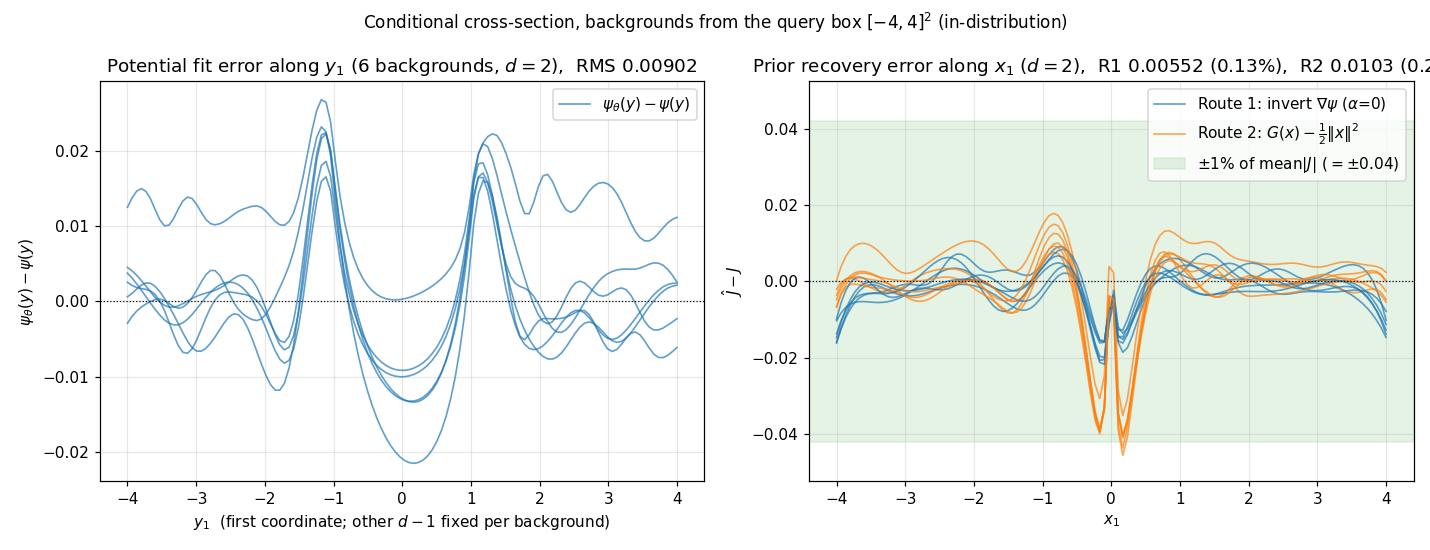

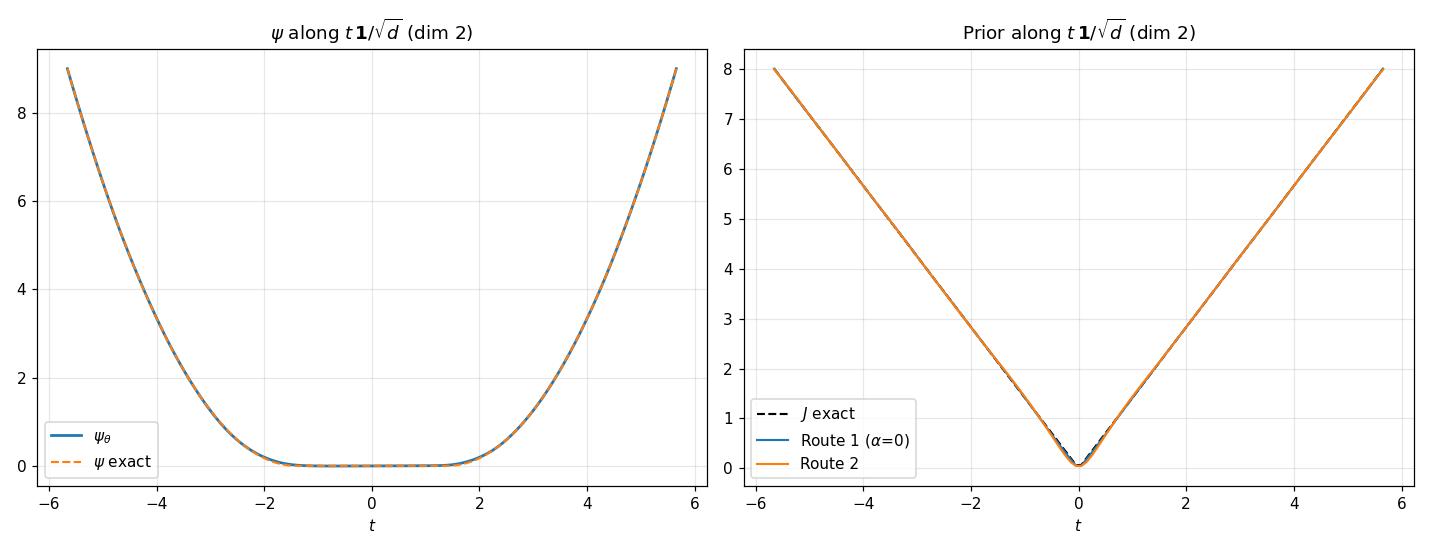

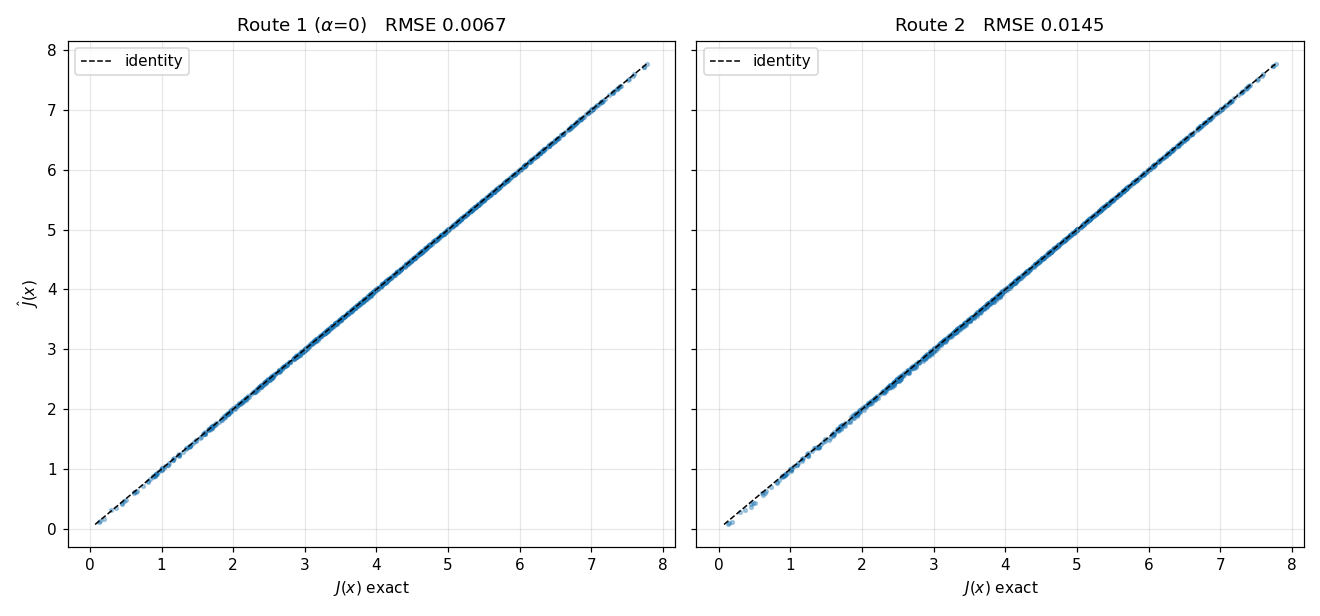

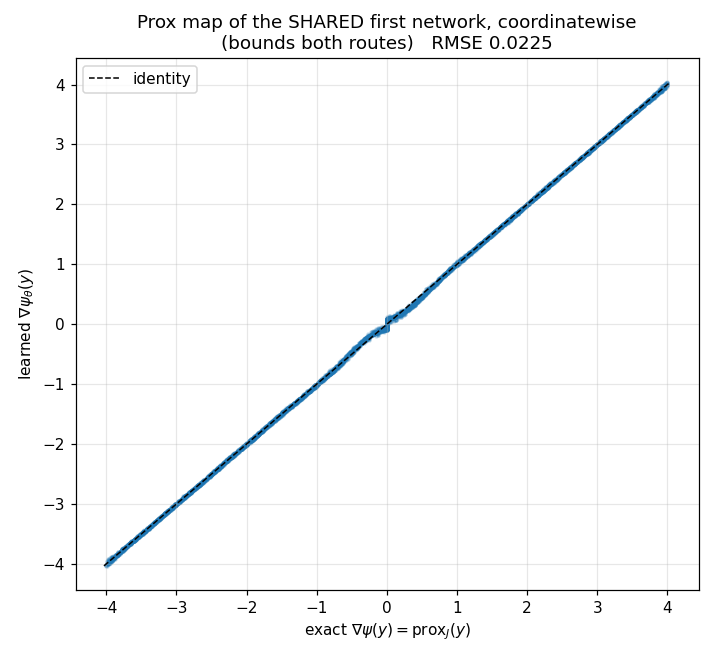

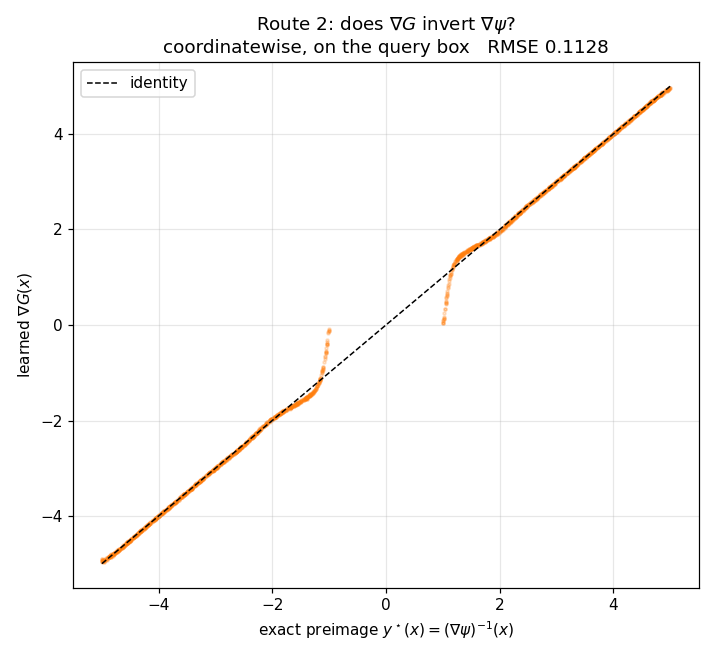

### d = 4

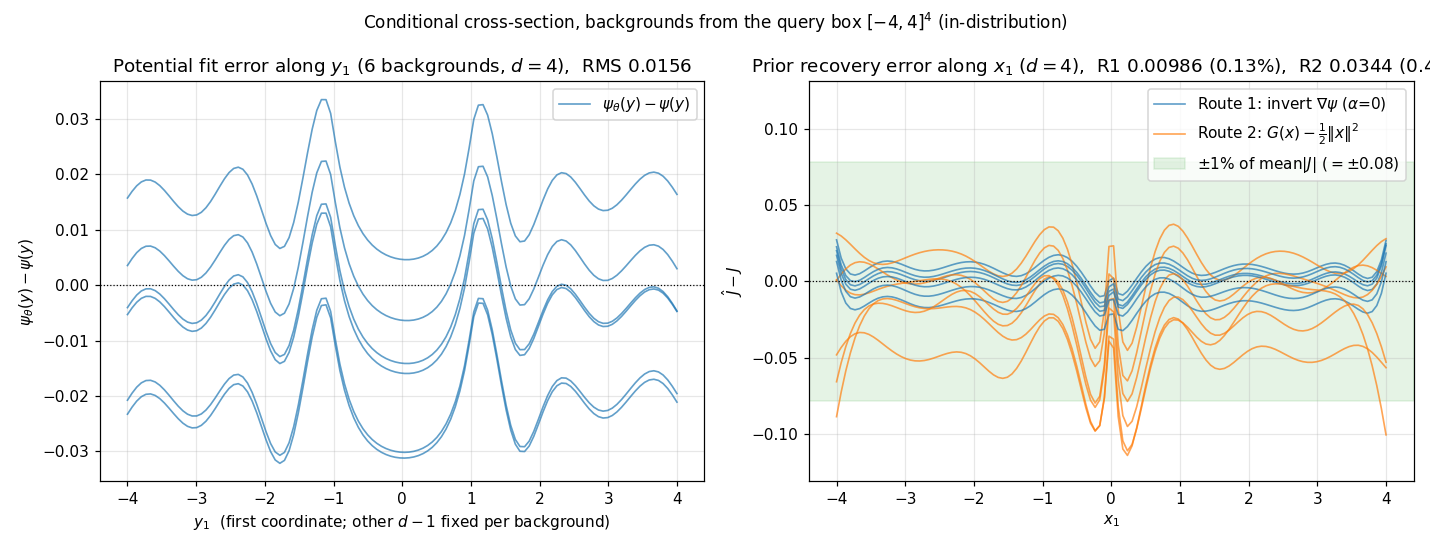

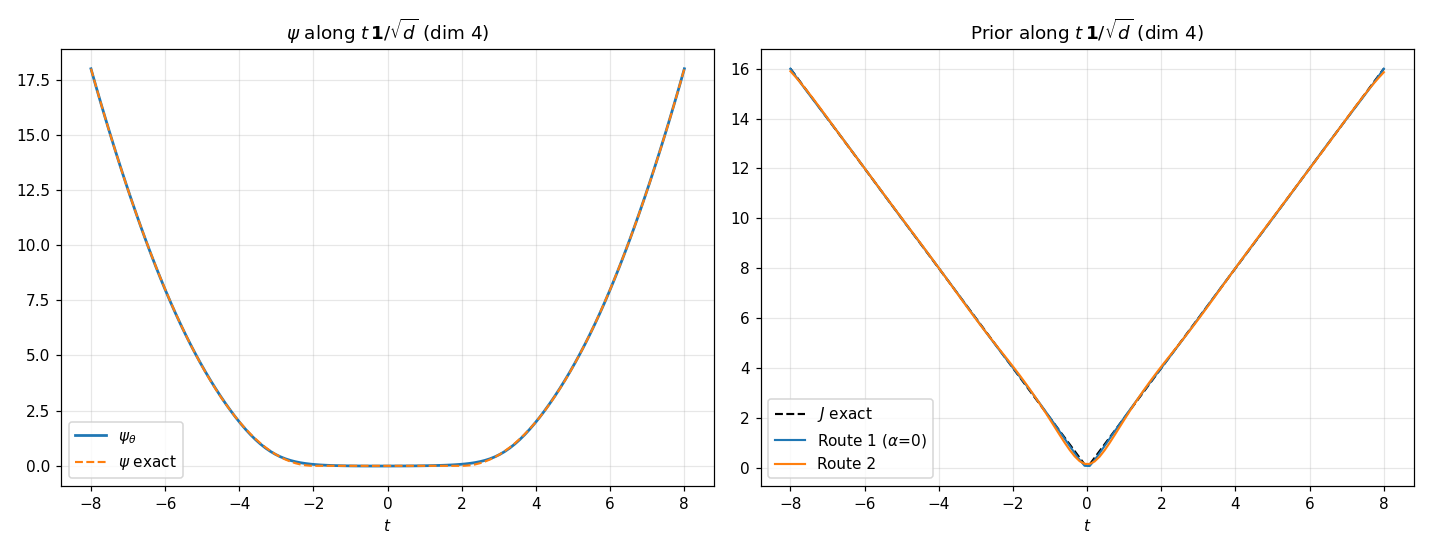

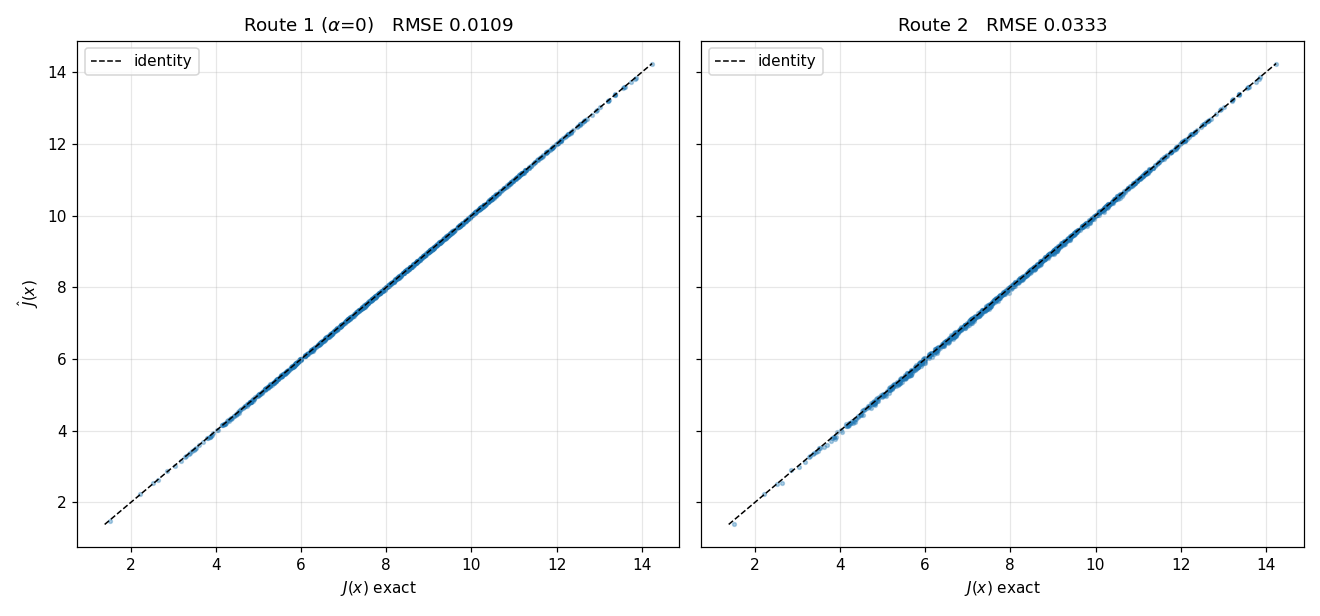

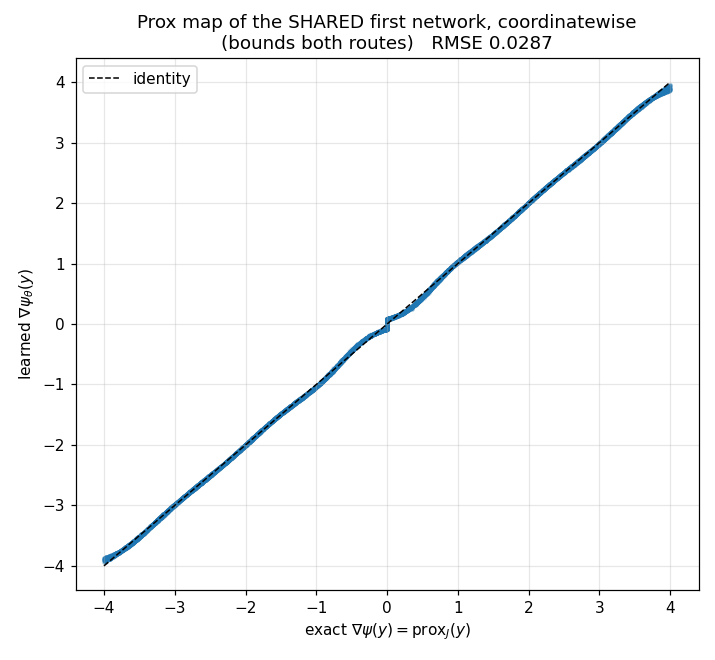

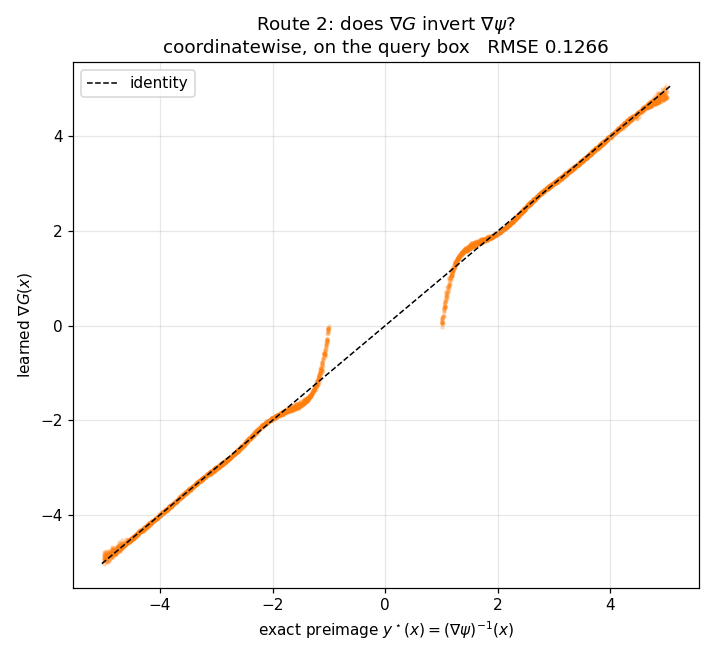

### d = 8

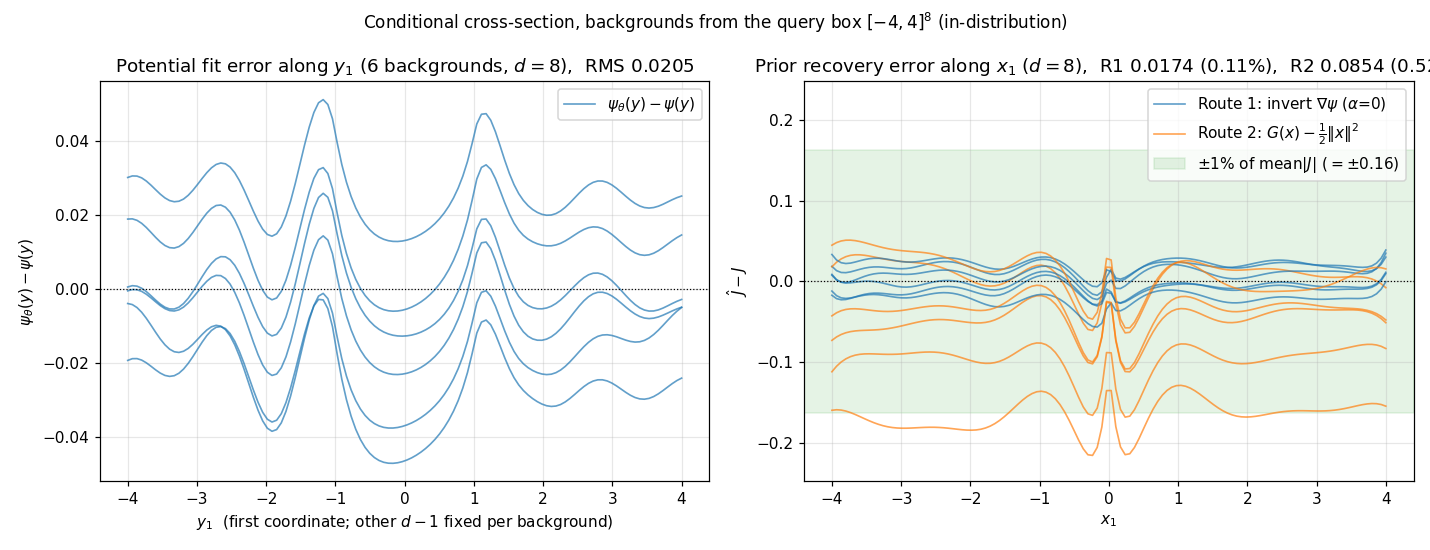

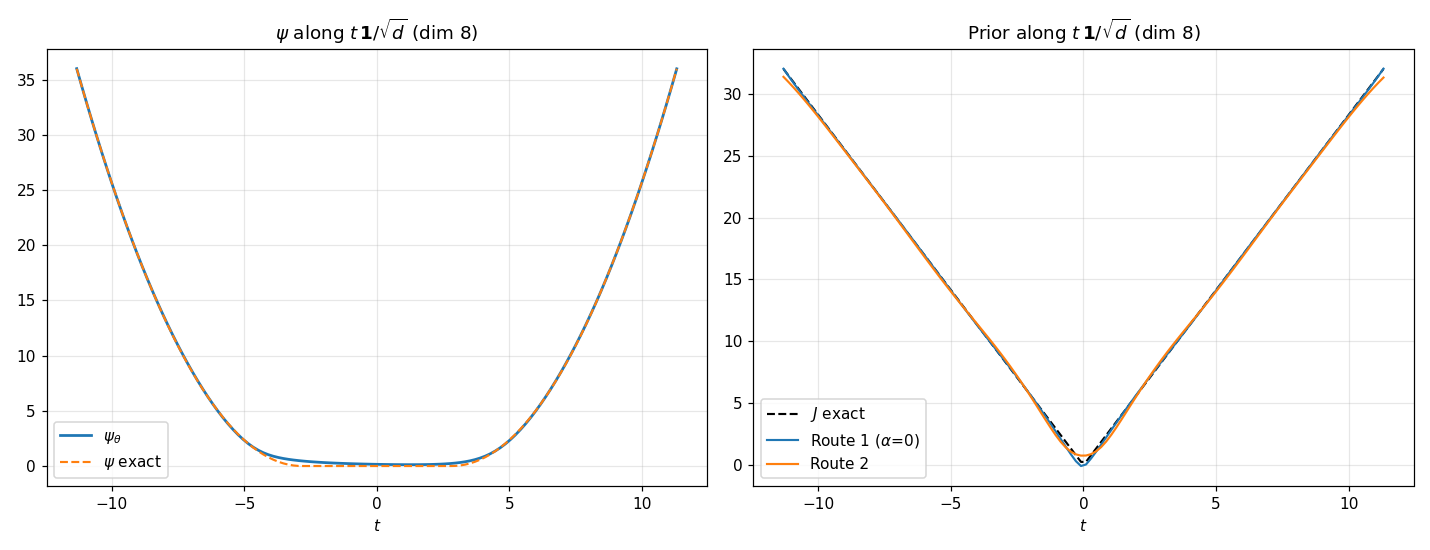

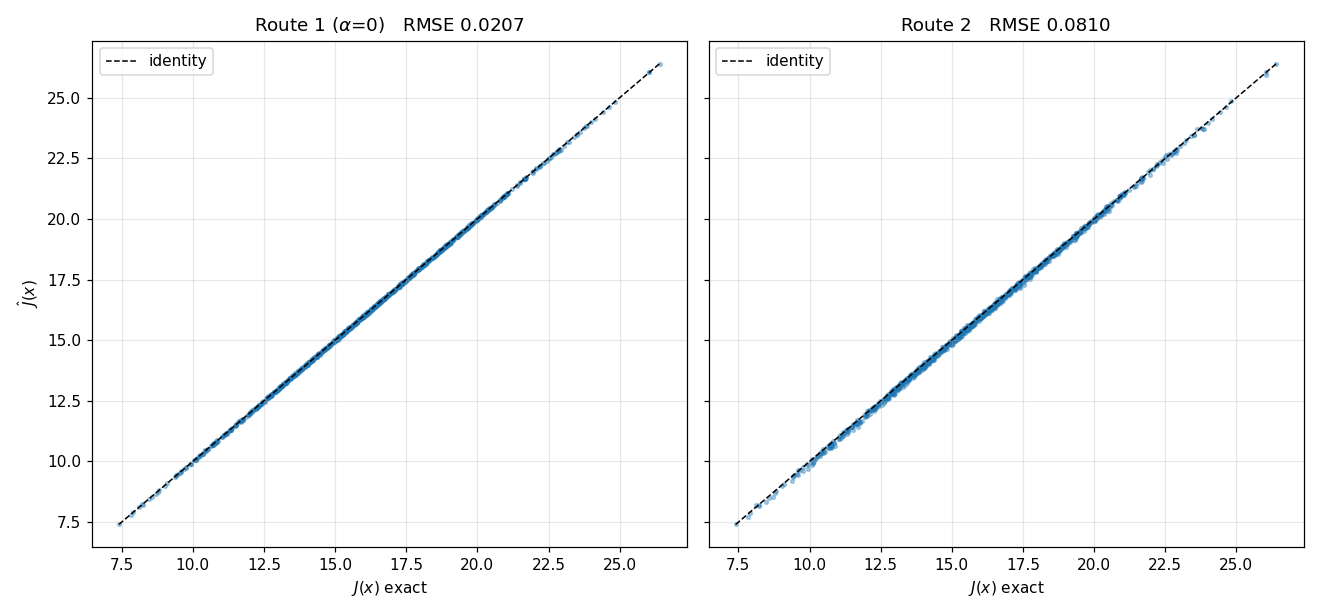

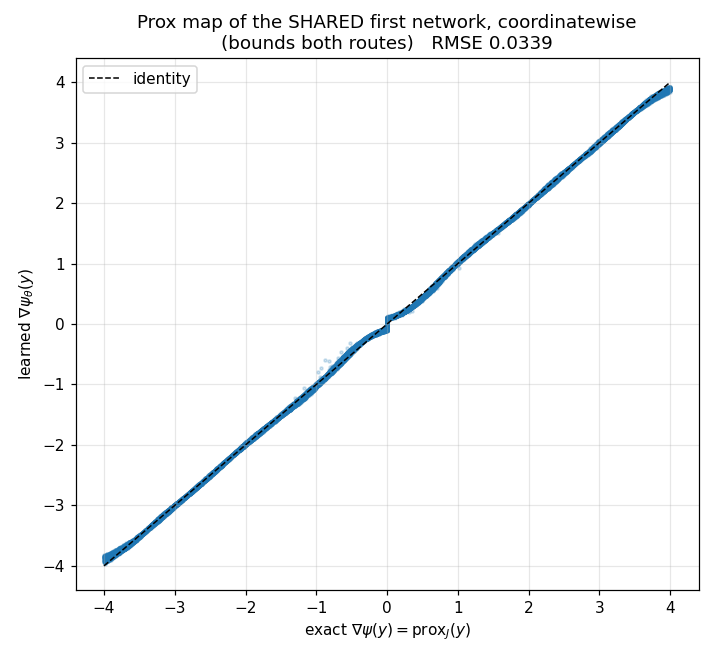

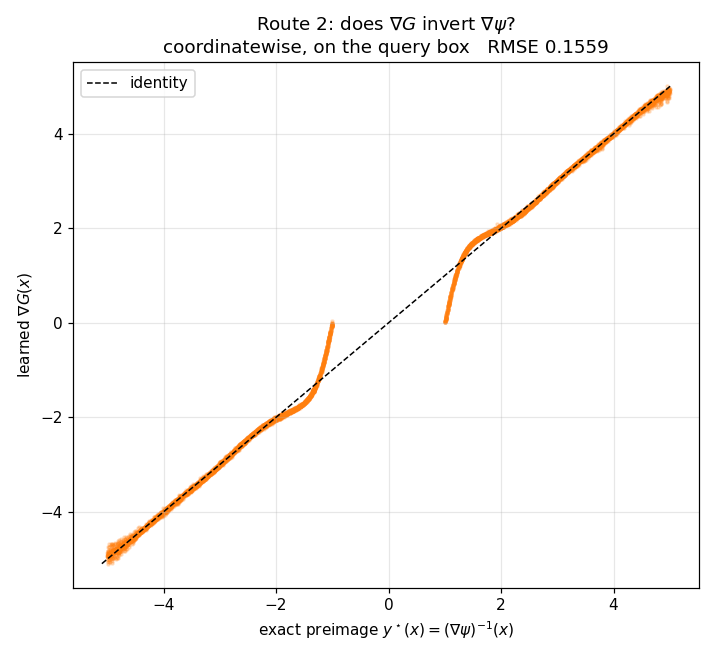

### d = 16

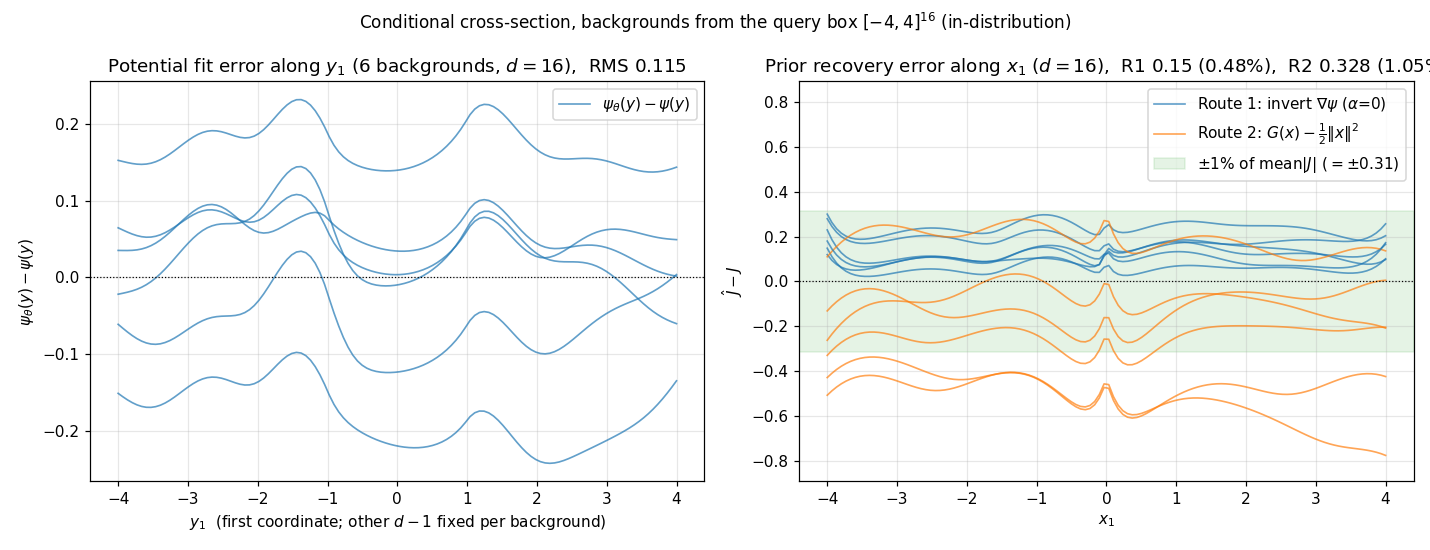

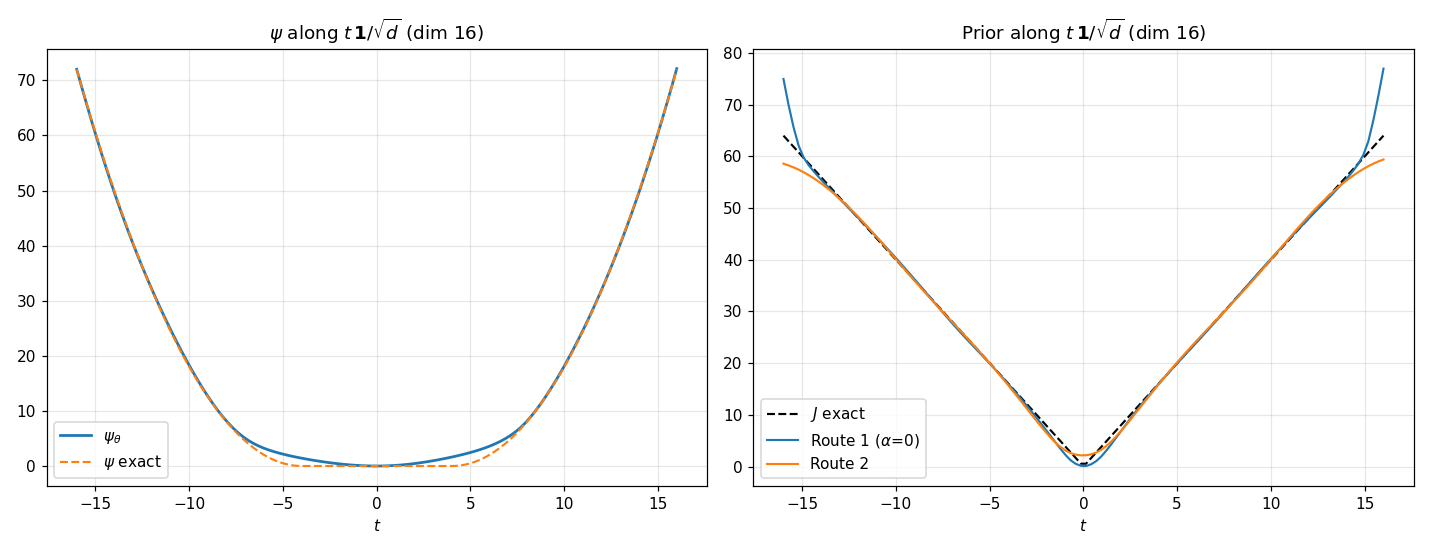

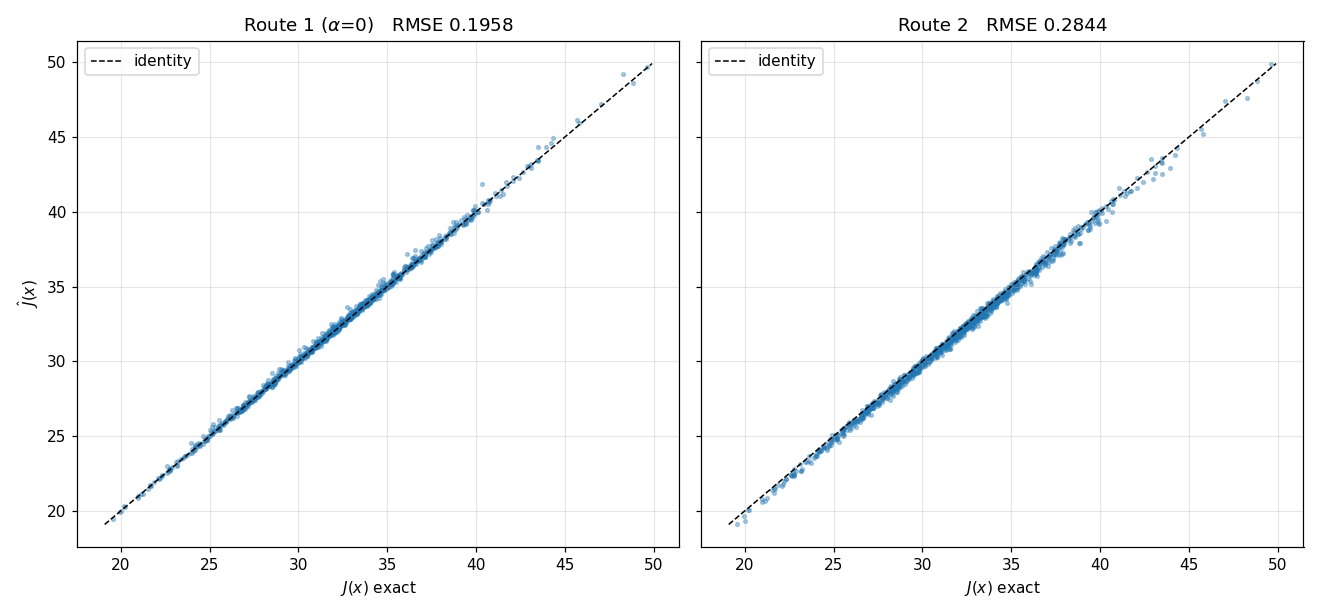

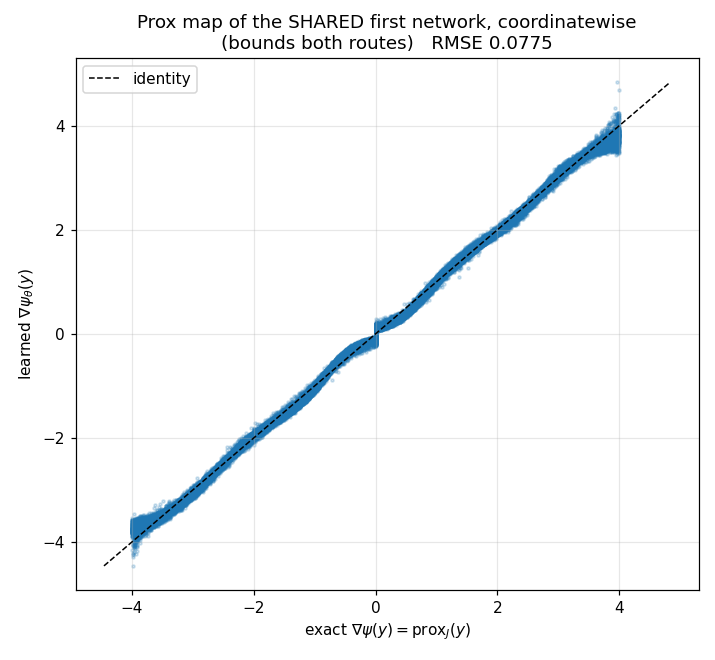

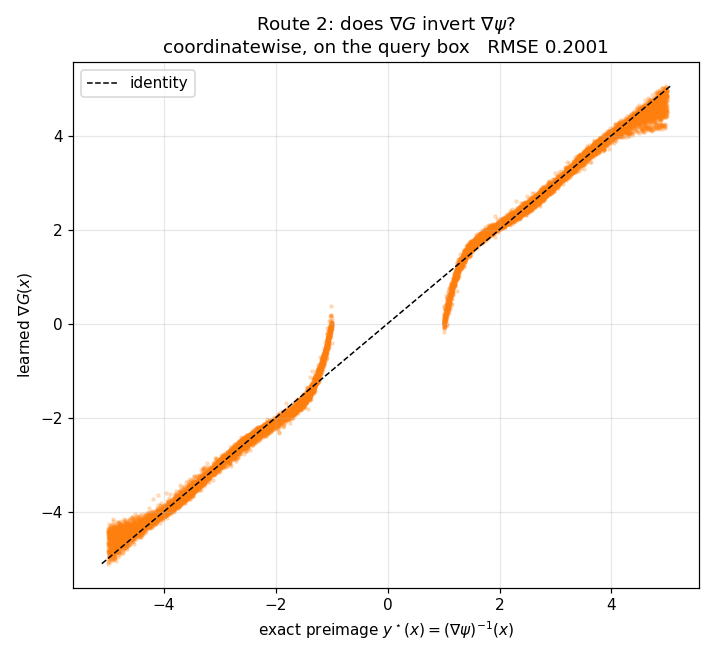

### d = 32

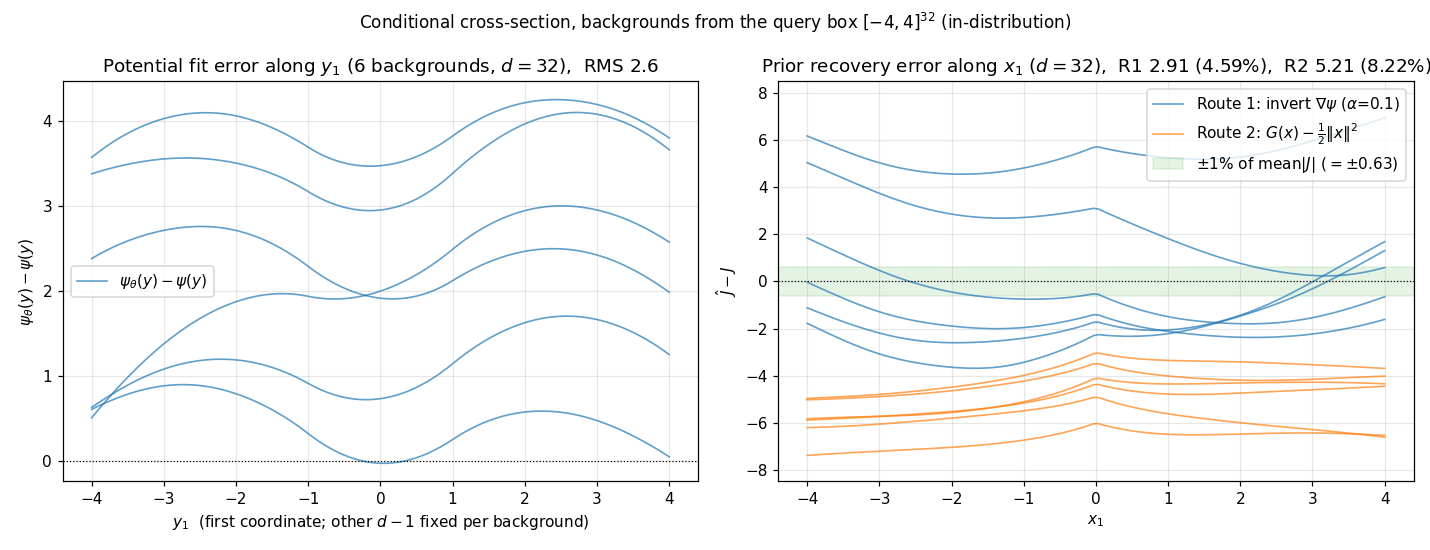

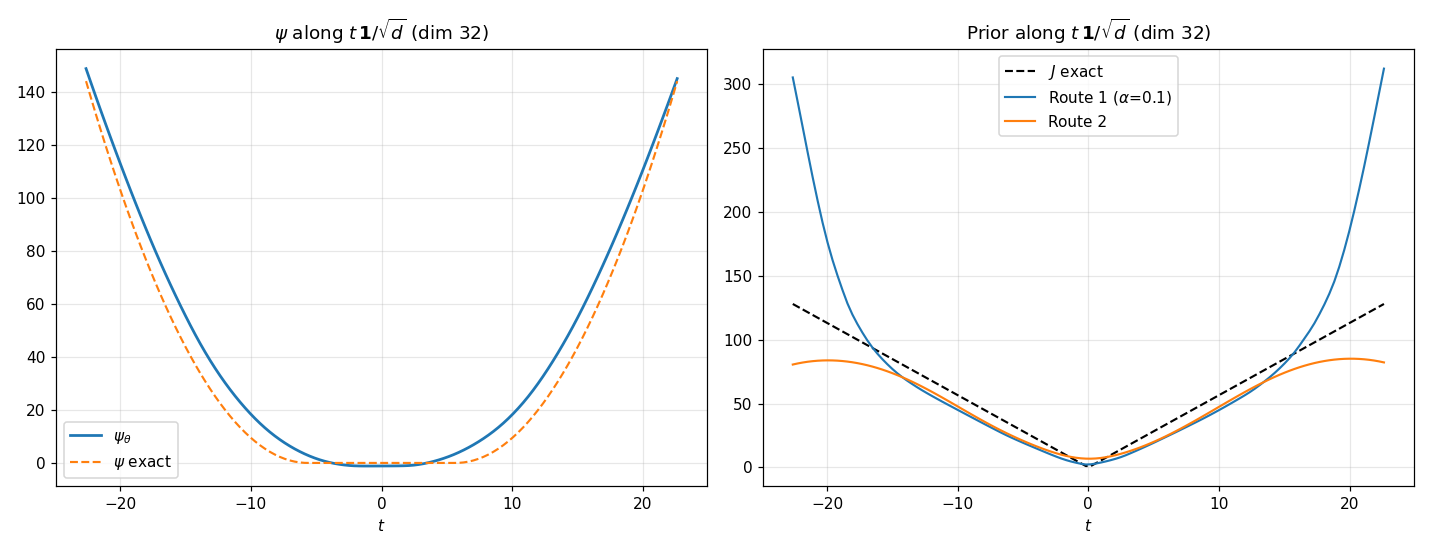

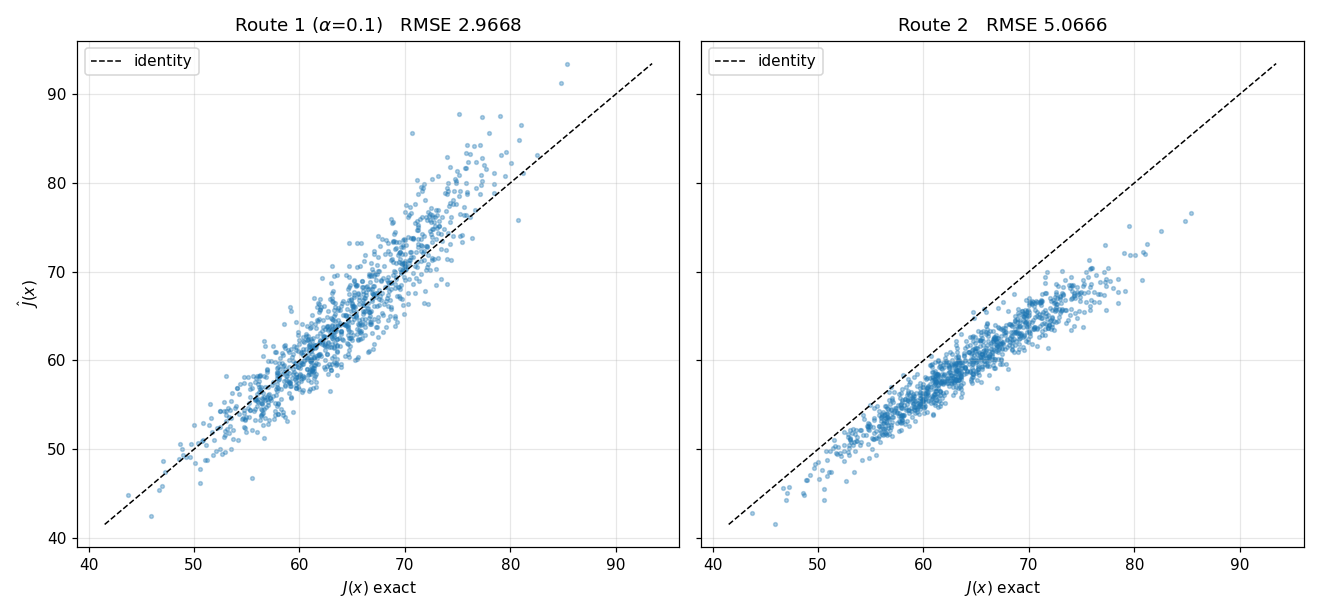

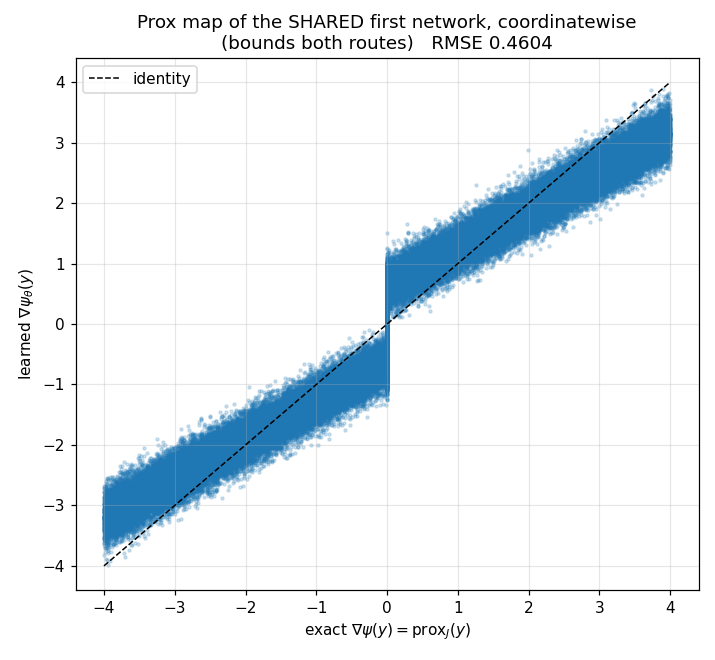

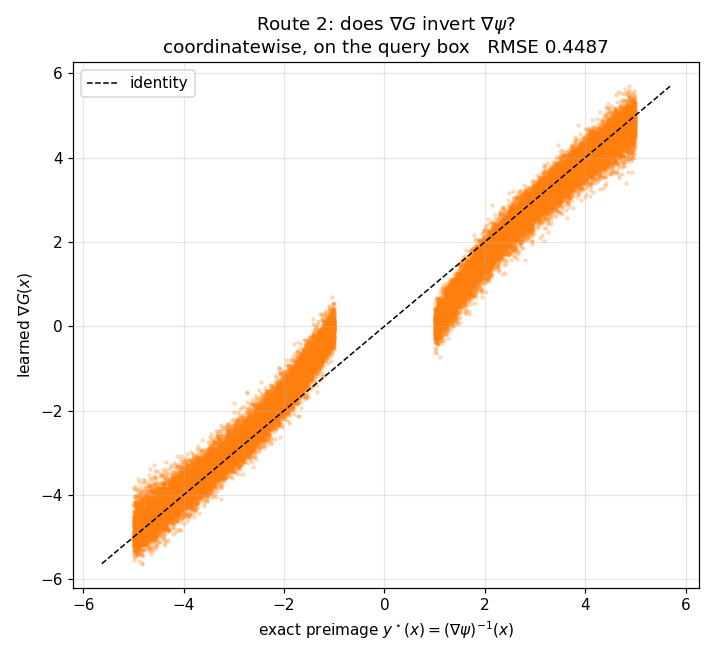

### d = 64

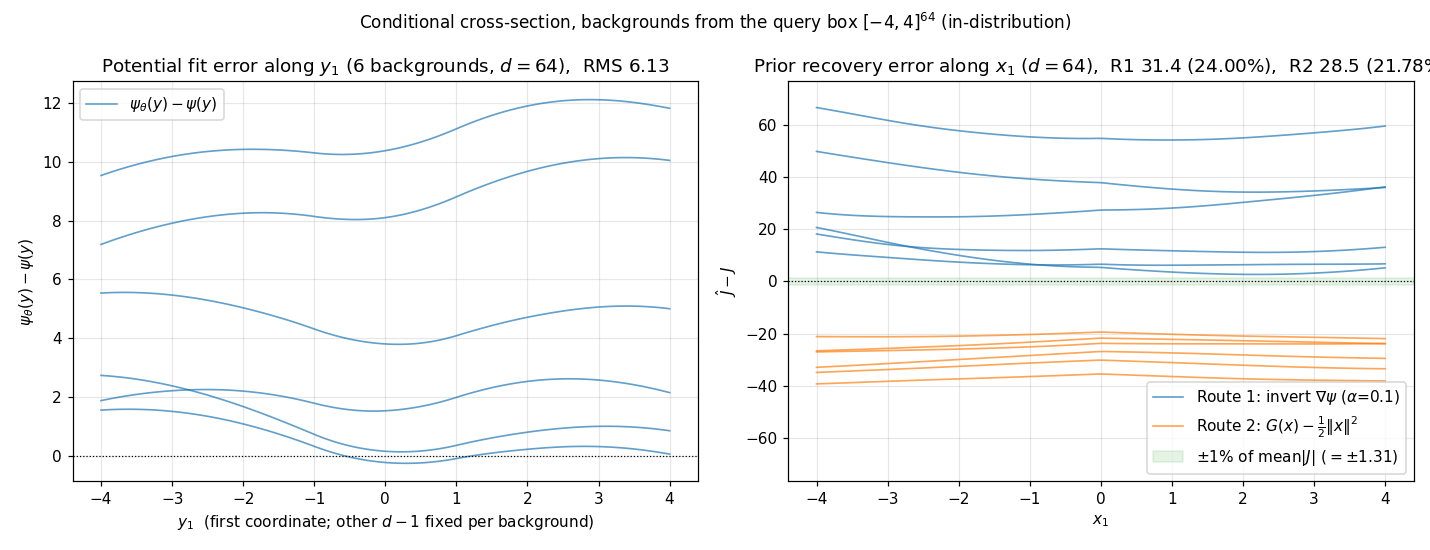

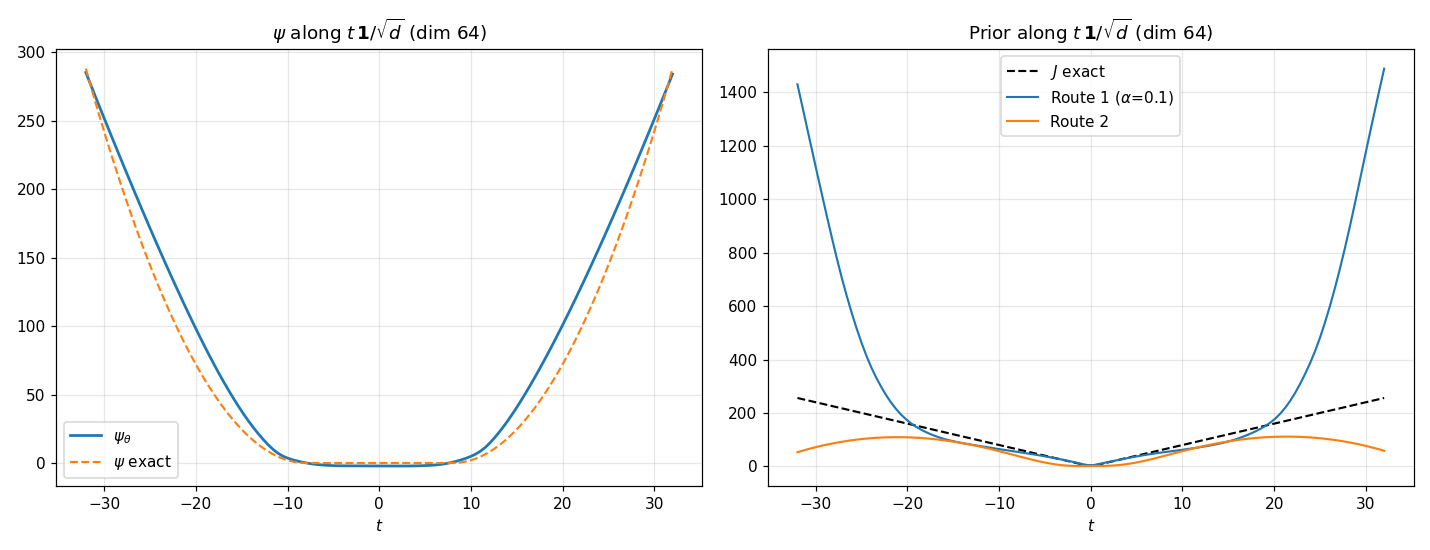

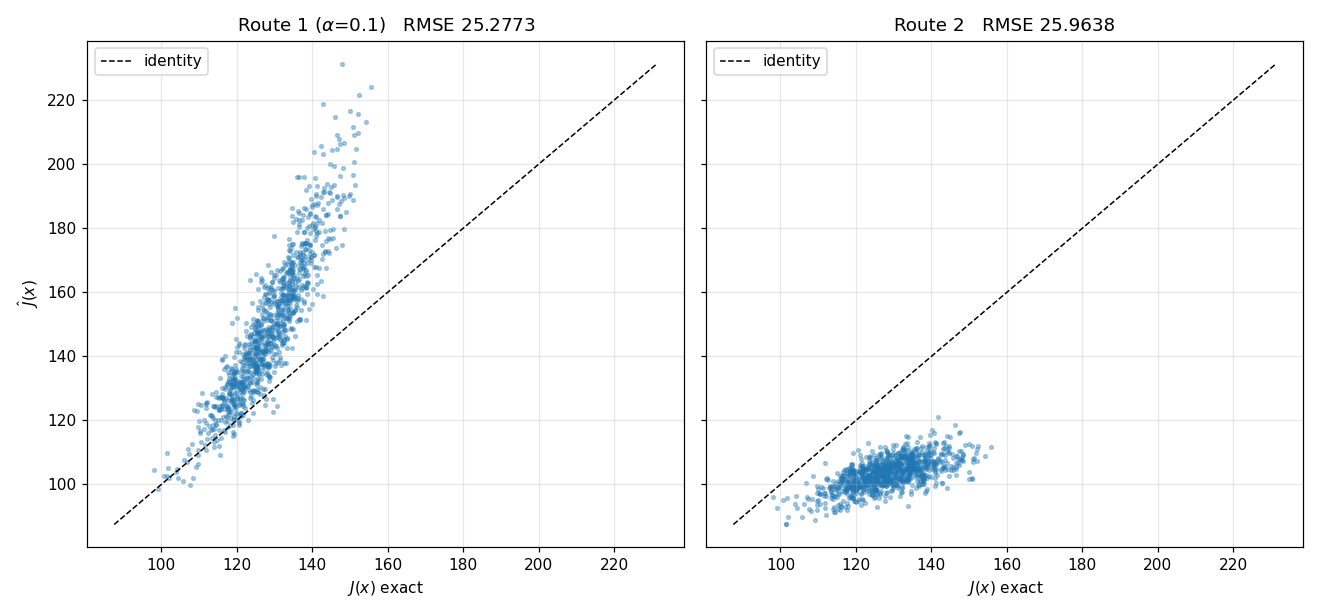

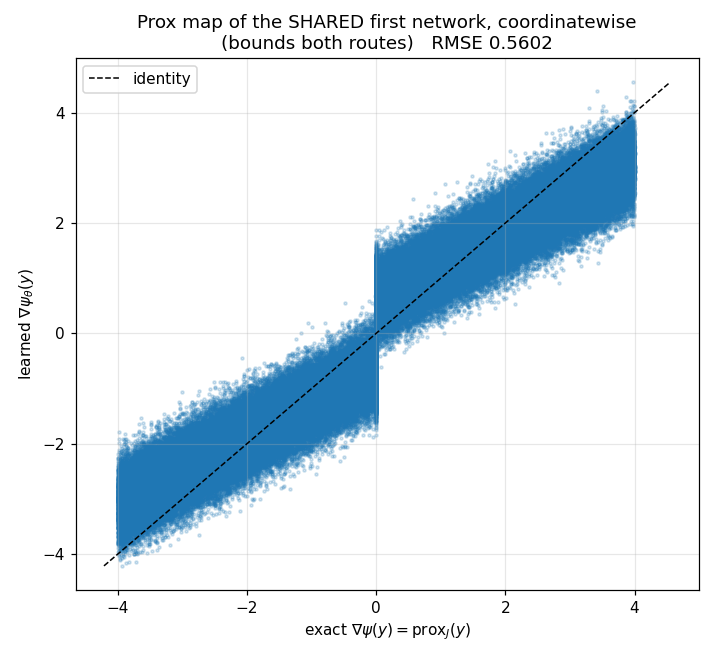

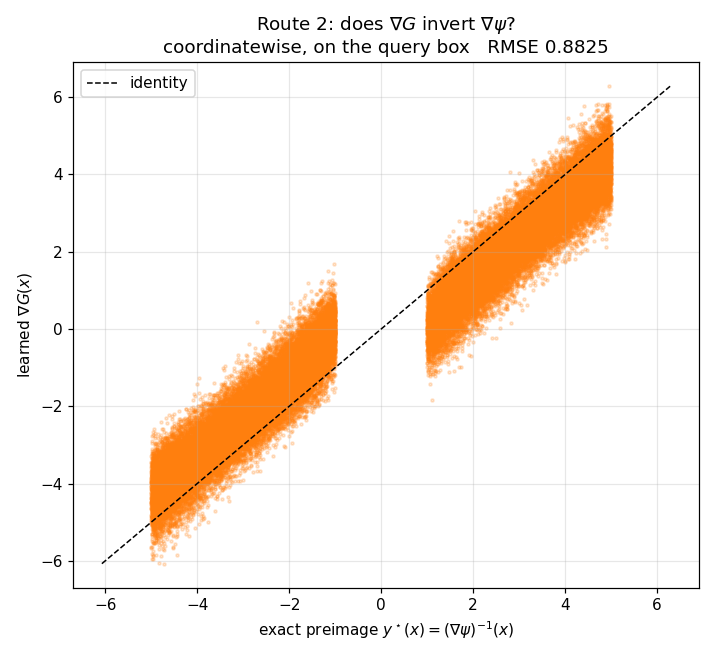

In [3]:
for d in DIMS:
    display(Markdown(f"### d = {d}"))
    for p in render(FAMILY, d, a=A, n_eval=N_EVAL):
        display(Image(filename=p, width=950))

## Rerunning the pipeline

Set `RETRAIN = True` in the parameters cell to retrain both networks from scratch under the exact protocol above (`bin/_run.py` defaults; roughly $45$ minutes per dimension on CPU). The run is written under the name `<family>_<d>D_retrain`, so it cannot clobber the production checkpoints; drop the suffix deliberately if you mean to replace them. Runs at $d > 8$ are opt-in by project policy and must be cleared first.

In [4]:
if RETRAIN:
    if RETRAIN_DIM > 8:
        raise RuntimeError("runs at d > 8 are opt-in by project policy; clear them first")
    from _run import run
    metrics = run(f"{FAMILY}_{RETRAIN_DIM}D_retrain", family.config(RETRAIN_DIM), dim=RETRAIN_DIM)